In [2]:
!uv sync

Using CPython 3.12.13 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 116 packages in 854ms
Prepared 110 packages in 10.57s
Installed 110 packages in 345ms
 + anyio==4.13.0
 + argon2-cffi==25.1.0
 + argon2-cffi-bindings==25.1.0
 + arrow==1.4.0
 + asttokens==3.0.1
 + async-lru==2.3.0
 + attrs==26.1.0
 + babel==2.18.0
 + beautifulsoup4==4.14.3
 + bleach==6.3.0
 + certifi==2026.2.25
 + cffi==2.0.0
 + charset-normalizer==3.4.6
 + comm==0.2.3
 + contourpy==1.3.3
 + cycler==0.12.1
 + debugpy==1.8.20
 + decorator==5.2.1
 + defusedxml==0.7.1
 + executing==2.2.1
 + fastjsonschema==2.21.2
 + fonttools==4.62.1
 + fqdn==1.5.1
 + h11==0.16.0
 + httpcore==1.0.9
 + httpx==0.28.1
 + idna==3.11
 + ipykernel==7.2.0
 + ipython==9.11.0
 + ipython-pygments-lexers==1.1.1
 + ipywidgets==8.1.8
 + isoduration==20.11.0
 + jedi==0.19.2
 + jinja2==3.1.6
 + json5==0.13.0
 + jsonpointer==3.1.1
 + jsonschema==4.26.0
 + jsonschema-specifications==2025.9.1
 + jupyter==1.1.1
 + jupyter-

## Download data

New York City yellow taxi trips from 2024.

In [3]:
import os
import subprocess

DATA_DIR = "data"
if not os.path.exists(DATA_DIR):
    os.mkdir(DATA_DIR)


for month in range(1, 13):
    if not os.path.exists(f"{DATA_DIR}/{month}.parquet"):
        subprocess.run(
            [
                "wget",
                f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-{month:02}.parquet",
                "-O",
                f"{DATA_DIR}/{month}.parquet",
            ]
        )


total_size = sum(
    os.path.getsize(f"{DATA_DIR}/{month}.parquet") for month in range(1, 13)
)  # bytes
total_size_mb = total_size // (1024 * 1024)
print(f"Total dataset size: {total_size_mb} MB")

Total dataset size: 660 MB


Download mapping for location IDs

In [4]:
if not os.path.exists(f"{DATA_DIR}/taxi_zone_lookup.csv"):
    subprocess.run(
        [
            "wget",
            "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
            "-O",
            f"{DATA_DIR}/taxi_zone_lookup.csv",
        ]
    )

## **1. Data reading**

### Load all 2024 months of taxi rides

In [7]:
import polars as pl

def get_monthly_data(data_dir: str, start_month: int, end_month: int, unit="ms"):
    eager_dfs = []

    for month in range(start_month, end_month + 1):
        df = pl.scan_parquet(f"{data_dir}/{month}.parquet")

        df = df.with_columns([
             pl.col("tpep_pickup_datetime").dt.cast_time_unit("ms"),
             pl.col("tpep_dropoff_datetime").dt.cast_time_unit("ms"),
        ])

        eager_dfs.append(df)

    return pl.concat(eager_dfs)

In [8]:
df_2024 = get_monthly_data(DATA_DIR, 1, 12)

In [ ]:
df_2024.collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ms],datetime[ms],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-12-31 23:32:00,2024-12-31 23:56:00,null,10.71,null,null,16,7,0,-4.13,0.0,0.5,0.0,0.0,1.0,-2.63,null,null
2,2024-12-31 23:05:00,2024-12-31 23:18:00,null,4.56,null,null,252,16,0,-1.68,0.0,0.5,0.0,0.0,1.0,-0.18,null,null
2,2024-12-31 23:03:16,2024-12-31 23:28:35,null,3.94,null,null,181,255,0,4.46,0.0,0.5,5.19,0.0,1.0,11.15,null,null


### Load taxi zone lookup data


In [ ]:
df_taxi_zones = pl.read_csv("data/taxi_zone_lookup.csv")
df_taxi_zones

LocationID,Borough,Zone,service_zone
i64,str,str,str
1,"""EWR""","""Newark Airport""","""EWR"""
2,"""Queens""","""Jamaica Bay""","""Boro Zone"""
3,"""Bronx""","""Allerton/Pelham Gardens""","""Boro Zone"""
4,"""Manhattan""","""Alphabet City""","""Yellow Zone"""
5,"""Staten Island""","""Arden Heights""","""Boro Zone"""
…,…,…,…
261,"""Manhattan""","""World Trade Center""","""Yellow Zone"""
262,"""Manhattan""","""Yorkville East""","""Yellow Zone"""
263,"""Manhattan""","""Yorkville West""","""Yellow Zone"""


In [ ]:
df_taxi_zones = df_taxi_zones.lazy()

### Include only rides starting in 2024 and ending at most at 01.01.2025

In [9]:
from datetime import date

df_2024 = df_2024.filter(
    (pl.col("tpep_pickup_datetime").dt.year() == 2024) &
    (pl.col("tpep_dropoff_datetime").dt.date() <= date(2025, 1, 1))
)
df_2024.collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
i32,datetime[ms],datetime[ms],i64,f64,i64,str,i32,i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,"""N""",186,79,2,17.7,1.0,0.5,0.0,0.0,1.0,22.7,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,"""N""",140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,"""N""",236,79,1,23.3,3.5,0.5,3.0,0.0,1.0,31.3,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,"""N""",79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,"""N""",211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-12-31 23:32:00,2024-12-31 23:56:00,null,10.71,null,null,16,7,0,-4.13,0.0,0.5,0.0,0.0,1.0,-2.63,null,null
2,2024-12-31 23:05:00,2024-12-31 23:18:00,null,4.56,null,null,252,16,0,-1.68,0.0,0.5,0.0,0.0,1.0,-0.18,null,null
2,2024-12-31 23:03:16,2024-12-31 23:28:35,null,3.94,null,null,181,255,0,4.46,0.0,0.5,5.19,0.0,1.0,11.15,null,null


### Optimize data types, particularly for integers and categorical strings

In [ ]:
df_2024.describe()

In [10]:
df_2024 = df_2024.with_columns(
    pl.col("VendorID").cast(pl.UInt8),
    pl.col("passenger_count").cast(pl.UInt8),
    pl.col("trip_distance").cast(pl.Float32),
    pl.col("RatecodeID").cast(pl.UInt8),
    pl.when(pl.col("store_and_fwd_flag") == "Y").then(True)
          .when(pl.col("store_and_fwd_flag") == "N").then(False)
          .otherwise(None)
          .alias("store_and_fwd_flag"),
    pl.col("PULocationID").cast(pl.UInt16),
    pl.col("DOLocationID").cast(pl.UInt16),
    pl.col("payment_type").cast(pl.UInt8),
    pl.col("fare_amount").cast(pl.Float32),
    pl.col("extra").cast(pl.Float32),
    pl.col("mta_tax").cast(pl.Float32),
    pl.col("tip_amount").cast(pl.Float32),
    pl.col("tolls_amount").cast(pl.Float32),
    pl.col("improvement_surcharge").cast(pl.Float32),
    pl.col("total_amount").cast(pl.Float32),
    pl.col("congestion_surcharge").cast(pl.Float32),
    pl.col("Airport_fee").cast(pl.Float32)
)

In [ ]:
df_2024

In [ ]:
df_2024.collect()

## **2. Data cleaning and filtering**

### Fill NULL values in passengers_count with 1


In [11]:
df_2024 = df_2024.with_columns(
    pl.col("passenger_count").fill_null(1)
)

In [ ]:
df_2024.collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
u8,datetime[ms],datetime[ms],u8,f32,u8,bool,u16,u16,u8,f32,f32,f32,f32,f32,f32,f32,f32,f32
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,false,186,79,2,17.700001,1.0,0.5,0.0,0.0,1.0,22.700001,2.5,0.0
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,false,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,false,236,79,1,23.299999,3.5,0.5,3.0,0.0,1.0,31.299999,2.5,0.0
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,false,79,211,1,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,false,211,148,1,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-12-31 23:32:00,2024-12-31 23:56:00,1,10.71,null,null,16,7,0,-4.13,0.0,0.5,0.0,0.0,1.0,-2.63,null,null
2,2024-12-31 23:05:00,2024-12-31 23:18:00,1,4.56,null,null,252,16,0,-1.68,0.0,0.5,0.0,0.0,1.0,-0.18,null,null
2,2024-12-31 23:03:16,2024-12-31 23:28:35,1,3.94,null,null,181,255,0,4.46,0.0,0.5,5.19,0.0,1.0,11.15,null,null


### Remove rides with zero passengers


In [12]:
df_2024 = df_2024.filter(pl.col("passenger_count") > 0)

### If a ride has over 6 passengers, replace the value with 6

In [ ]:
df_2024 = df_2024.with_columns(
    pl.when(pl.col("passenger_count") > 6)
    .then(6)
    .otherwise(pl.col("passenger_count"))
    .alias("passenger_count")
)

### Remove rides lasting over 2 hours

In [ ]:
df_2024 = df_2024.with_columns([
    ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
     .dt.total_minutes())
     .alias("trip_duration")
]).filter(pl.col("trip_duration") <= 120)

### In all money-related columns, replace values with absolute value to fix negative amounts

In [ ]:
import polars.selectors as cs

df_2024 = df_2024.with_columns(
    cs.by_name("fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
               "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee")
    .abs()
)


### Remove rides with over 1000 dollars in any money-related column

In [ ]:
df_2024 = df_2024.filter(
    pl.all_horizontal(
        cs.by_name("fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
                   "improvement_surcharge", "total_amount", "congestion_surcharge", "Airport_fee")
        <= 1000
    )
)

### Remove rows with values of `RatecodeID` or `VendorID` missing or outside those defined in the data dictionary

In [ ]:
df_2024 = df_2024.filter(
    pl.col("RatecodeID").is_between(1, 6),
    pl.col("VendorID").is_in([1, 2])
)

## **3. Data transformation**

### Combine payment type values for "No charge", "Dispute", "Unknown" and "Voided trip" into one type, so we have only credit card, cash, or other

In [ ]:
df_2024 = df_2024.with_columns(
    pl.col("payment_type").replace_strict(
        {
            1: "Credit card",
            2: "Cash",
            3: "Other", # No charge
            4: "Other", # Dispute
            5: "Other", # Unknown
            6: "Other"  # Voided trip
        },
        default="Other"
    ).alias("payment_group")
)

### Replace `PULocationID` and `DOLocationID` with borough names by joining taxi zone lookup and removing unnecessary columns


In [ ]:
df_2024 = (
    df_2024
    .join(df_taxi_zones, left_on="PULocationID", right_on="LocationID", how="left")
    .rename({"Borough": "pu_borough"})
    .drop("Zone", "service_zone")

    .join(df_taxi_zones, left_on="DOLocationID", right_on="LocationID", how="left")
    .rename({"Borough": "do_borough"})
    .drop("Zone", "service_zone")
)


### Add boolean variable `is_airport_ride`, true if there is non-zero airport fee

In [ ]:
df_2024 = df_2024.with_columns(
     pl.when(pl.col("Airport_fee") != 0).then(True)
          .when(pl.col("Airport_fee") == 0).then(False)
          .otherwise(None)
          .alias("is_airport_ride"),
)

### Add boolean variable `is_rush_hour`, rush hours are defined as 6:30–9:30 and 15:30-20:00 during weekdays

In [ ]:
df_2024 = df_2024.with_columns(
    pl.col("tpep_pickup_datetime").dt.time().alias("pickup_time"),
    pl.col("tpep_pickup_datetime").dt.weekday().alias("pickup_weekday")
).with_columns(
    (
         (pl.col("pickup_weekday") <= 5) & (
          (pl.col("pickup_time").is_between(pl.time(6, 30), pl.time(9, 30))) |
           (pl.col("pickup_time").is_between(pl.time(15, 30), pl.time(20, 0)))
      )).alias("is_rush_hour")
  ).drop("pickup_time", "pickup_weekday")

## **4. Feature extraction**

### apply dummy encoding to features:
 - payment type
 - pickup borough
 - dropoff borough


In [ ]:
df_2024 = df_2024.collect().to_dummies(["payment_type", "pu_borough", "do_borough"])

### Add integer variables for counting daily events:
 - total number of rides (target variable)
 - number of airport rides
 - number of rush hour rides

#### total number of rides (target variable)


In [ ]:
total_number_of_rides = (
    df_2024
    .group_by(pl.col("tpep_pickup_datetime").dt.date())
    .agg(pl.len().alias("total_number_of_rides"))
)

In [ ]:
total_number_of_rides

tpep_pickup_datetime,total_number_of_rides
date,u32
2024-03-30,93903
2024-06-12,111343
2024-12-17,117946
2024-03-23,96870
2024-07-23,96784
…,…
2024-05-26,71784
2024-03-07,108409
2024-11-01,117948


#### number of airport rides

In [ ]:
airport_rides = (
    df_2024
    .filter(pl.col("is_airport_ride") == True)
    .group_by(pl.col("tpep_pickup_datetime").dt.date())
    .agg(pl.len().alias("total_number_of_rides"))
)

In [ ]:
airport_rides

tpep_pickup_datetime,total_number_of_rides
date,u32
2024-09-19,10287
2024-12-10,10328
2024-07-27,7270
2024-02-20,8737
2024-04-16,8718
…,…
2024-03-01,8301
2024-03-22,8707
2024-05-20,11237


#### number of rush hour rides

In [ ]:
rush_hour_rides = (
    df_2024
    .filter(pl.col("is_rush_hour") == True)
    .group_by(pl.col("tpep_pickup_datetime").dt.date())
    .agg(pl.len().alias("total_number_of_rides"))
)

In [ ]:
rush_hour_rides

tpep_pickup_datetime,total_number_of_rides
date,u32
2024-09-06,42231
2024-04-10,40983
2024-04-22,34230
2024-03-26,41022
2024-08-26,31601
…,…
2024-09-25,44279
2024-11-21,54542
2024-05-29,43468


#### daily events

In [ ]:
daily_events = (
    df_2024
    .group_by(pl.col("tpep_pickup_datetime").dt.date().alias("date"))
    .agg([
        pl.len().alias("total_number_of_rides"),
        pl.col("is_airport_ride").sum().alias("airport_rides"),
        pl.col("is_rush_hour").sum().alias("rush_hour_rides")
    ])
    .sort("date")
)

In [ ]:
daily_events

date,total_number_of_rides,airport_rides,rush_hour_rides
date,u32,u32,u32
2024-01-01,69541,8352,19360
2024-01-02,71444,9828,30554
2024-01-03,78399,9140,32924
2024-01-04,97896,8270,43112
2024-01-05,97958,7460,40150
…,…,…,…
2024-12-27,78783,7276,30014
2024-12-28,81427,6848,0
2024-12-29,73177,7751,0


### Add features aggregating daily rides information:
 - average fare amount
 - median distance
 - sum of total amounts
 - total amount paid by card, cash, and other
 - total congestion surcharge
 - total number of passengers


In [ ]:
df_2024

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type_1,payment_type_2,payment_type_3,payment_type_4,payment_type_5,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration,payment_group,pu_borough_Bronx,pu_borough_Brooklyn,pu_borough_EWR,pu_borough_Manhattan,pu_borough_N/A,pu_borough_Queens,pu_borough_Staten Island,pu_borough_Unknown,do_borough_Bronx,do_borough_Brooklyn,do_borough_EWR,do_borough_Manhattan,do_borough_N/A,do_borough_Queens,do_borough_Staten Island,do_borough_Unknown,is_airport_ride,is_rush_hour,quarter,month,day_of_month,day_of_week,is_weekend
u8,datetime[ms],datetime[ms],u8,f32,u8,bool,u16,u16,u8,u8,u8,u8,u8,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,bool,bool,i8,i8,i8,i8,bool
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,false,186,79,0,1,0,0,0,17.700001,1.0,0.5,0.0,0.0,1.0,22.700001,2.5,0.0,19,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,false,140,236,1,0,0,0,0,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,false,236,79,1,0,0,0,0,23.299999,3.5,0.5,3.0,0.0,1.0,31.299999,2.5,0.0,17,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,false,79,211,1,0,0,0,0,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,8,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,false,211,148,1,0,0,0,0,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-12-31 22:56:33,2024-12-31 23:05:57,1,1.9,1,false,237,262,1,0,0,0,0,12.1,1.0,0.5,1.88,0.0,1.0,18.98,2.5,0.0,9,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,4,12,31,2,false
2,2024-12-31 23:18:37,2024-12-31 23:32:32,1,3.88,1,false,237,226,0,1,0,0,0,19.1,1.0,0.5,0.0,0.0,1.0,24.1,2.5,0.0,13,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,false,false,4,12,31,2,false
2,2024-12-31 23:08:52,2024-12-31 23:34:59,1,5.53,1,false,142,255,1,0,0,0,0,29.6,1.0,0.5,2.0,0.0,1.0,36.599998,2.5,0.0,26,"""Credit card""",0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,false,false,4,12,31,2,false


In [ ]:
daily_rides = (
    df_2024
    .group_by(pl.col("tpep_pickup_datetime").dt.date().alias("date"))
    .agg([
        pl.col("fare_amount").mean().alias("average_fare_amount"),
        pl.col("trip_distance").median().alias("median_distance"),
        pl.col("total_amount").sum().alias("total_amount_sum"),
        pl.col("total_amount").filter(pl.col("payment_group") == "Credit card").sum().alias("credit_card_total_amount"),
        pl.col("total_amount").filter(pl.col("payment_group") == "Cash").sum().alias("cash_total_amount"),
        pl.col("total_amount").filter(pl.col("payment_group") == "Other").sum().alias("other_total_amount"),
        pl.col("congestion_surcharge").sum().alias("total_congestion_surcharge"),
        pl.col("passenger_count").sum().alias("total_passengers")
    ])
    .sort("date")
)

### Add time features:
 - `quarter`
 - `month`
 - `day_of_month`
 - `day_of_week`
 - `is_weekend` (boolean)

In [ ]:
df_2024 = df_2024.with_columns([
    pl.col("tpep_pickup_datetime").dt.quarter().alias("quarter"),
    pl.col("tpep_pickup_datetime").dt.month().alias("month"),
    pl.col("tpep_pickup_datetime").dt.day().alias("day_of_month"),
    pl.col("tpep_pickup_datetime").dt.weekday().alias("day_of_week"),
    pl.col("tpep_pickup_datetime").dt.weekday().is_in([6, 7]).alias("is_weekend")
])

### Add column `date`, indicating day with given features

In [ ]:
df_2024 = df_2024.with_columns(
    pl.col("tpep_pickup_datetime").dt.date().alias("date")
)

### Make sure to exclude other columns, unnecessary for machine learning, e.g. IDs, timestamps, unused financial information

In [ ]:
df_2024

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type_1,payment_type_2,payment_type_3,payment_type_4,payment_type_5,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration,payment_group,pu_borough_Bronx,pu_borough_Brooklyn,pu_borough_EWR,pu_borough_Manhattan,pu_borough_N/A,pu_borough_Queens,pu_borough_Staten Island,pu_borough_Unknown,do_borough_Bronx,do_borough_Brooklyn,do_borough_EWR,do_borough_Manhattan,do_borough_N/A,do_borough_Queens,do_borough_Staten Island,do_borough_Unknown,is_airport_ride,is_rush_hour,quarter,month,day_of_month,day_of_week,is_weekend,date
u8,datetime[ms],datetime[ms],u8,f32,u8,bool,u16,u16,u8,u8,u8,u8,u8,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,bool,bool,i8,i8,i8,i8,bool,date
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,false,186,79,0,1,0,0,0,17.700001,1.0,0.5,0.0,0.0,1.0,22.700001,2.5,0.0,19,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,false,140,236,1,0,0,0,0,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,false,236,79,1,0,0,0,0,23.299999,3.5,0.5,3.0,0.0,1.0,31.299999,2.5,0.0,17,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,false,79,211,1,0,0,0,0,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,8,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,false,211,148,1,0,0,0,0,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2,2024-12-31 22:56:33,2024-12-31 23:05:57,1,1.9,1,false,237,262,1,0,0,0,0,12.1,1.0,0.5,1.88,0.0,1.0,18.98,2.5,0.0,9,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,4,12,31,2,false,2024-12-31
2,2024-12-31 23:18:37,2024-12-31 23:32:32,1,3.88,1,false,237,226,0,1,0,0,0,19.1,1.0,0.5,0.0,0.0,1.0,24.1,2.5,0.0,13,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,false,false,4,12,31,2,false,2024-12-31
2,2024-12-31 23:08:52,2024-12-31 23:34:59,1,5.53,1,false,142,255,1,0,0,0,0,29.6,1.0,0.5,2.0,0.0,1.0,36.599998,2.5,0.0,26,"""Credit card""",0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,false,false,4,12,31,2,false,2024-12-31


In [ ]:
df_clean_2024 = df_2024.drop(
    [
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "VendorID",
        "RatecodeID",
        "PULocationID",
        "DOLocationID",
        "store_and_fwd_flag",
        "fare_amount",
        "mta_tax",
        "extra",
        "tip_amount",
        "tolls_amount",
        "improvement_surcharge",
        "congestion_surcharge",
        "Airport_fee"
    ]
)

In [ ]:
df_clean_2024

passenger_count,trip_distance,payment_type_1,payment_type_2,payment_type_3,payment_type_4,payment_type_5,total_amount,trip_duration,payment_group,pu_borough_Bronx,pu_borough_Brooklyn,pu_borough_EWR,pu_borough_Manhattan,pu_borough_N/A,pu_borough_Queens,pu_borough_Staten Island,pu_borough_Unknown,do_borough_Bronx,do_borough_Brooklyn,do_borough_EWR,do_borough_Manhattan,do_borough_N/A,do_borough_Queens,do_borough_Staten Island,do_borough_Unknown,is_airport_ride,is_rush_hour,quarter,month,day_of_month,day_of_week,is_weekend,date
u8,f32,u8,u8,u8,u8,u8,f32,i64,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,bool,bool,i8,i8,i8,i8,bool,date
1,1.72,0,1,0,0,0,22.700001,19,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,1.8,1,0,0,0,0,18.75,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,4.7,1,0,0,0,0,31.299999,17,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,1.4,1,0,0,0,0,17.0,8,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,0.8,1,0,0,0,0,16.1,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,1.9,1,0,0,0,0,18.98,9,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,4,12,31,2,false,2024-12-31
1,3.88,0,1,0,0,0,24.1,13,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,false,false,4,12,31,2,false,2024-12-31
1,5.53,1,0,0,0,0,36.599998,26,"""Credit card""",0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,false,false,4,12,31,2,false,2024-12-31


### Properly name all columns

In [ ]:
df_clean_2024 = df_clean_2024.with_columns(
    pl.col("payment_type_1").alias("payment_type_Credit_card"),
    pl.col("payment_type_2").alias("payment_type_Cash"),
    pl.col("payment_type_3").alias("payment_type_No_charge"),
    pl.col("payment_type_4").alias("payment_type_Dispute"),
    pl.col("payment_type_5").alias("payment_type_Unknown")
)

df_clean_2024 = df_clean_2024.drop([
    "payment_type_1",
    "payment_type_2",
    "payment_type_3",
    "payment_type_4",
    "payment_type_5"
])

In [ ]:
df_clean_2024

passenger_count,trip_distance,total_amount,trip_duration,payment_group,pu_borough_Bronx,pu_borough_Brooklyn,pu_borough_EWR,pu_borough_Manhattan,pu_borough_N/A,pu_borough_Queens,pu_borough_Staten Island,pu_borough_Unknown,do_borough_Bronx,do_borough_Brooklyn,do_borough_EWR,do_borough_Manhattan,do_borough_N/A,do_borough_Queens,do_borough_Staten Island,do_borough_Unknown,is_airport_ride,is_rush_hour,quarter,month,day_of_month,day_of_week,is_weekend,date,payment_type_Credit_card,payment_type_Cash,payment_type_No_charge,payment_type_Dispute,payment_type_Unknown
u8,f32,f32,i64,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,bool,bool,i8,i8,i8,i8,bool,date,u8,u8,u8,u8,u8
1,1.72,22.700001,19,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01,0,1,0,0,0
1,1.8,18.75,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01,1,0,0,0,0
1,4.7,31.299999,17,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01,1,0,0,0,0
1,1.4,17.0,8,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01,1,0,0,0,0
1,0.8,16.1,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01,1,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
1,1.9,18.98,9,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,4,12,31,2,false,2024-12-31,1,0,0,0,0
1,3.88,24.1,13,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,false,false,4,12,31,2,false,2024-12-31,0,1,0,0,0
1,5.53,36.599998,26,"""Credit card""",0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,false,false,4,12,31,2,false,2024-12-31,1,0,0,0,0


### save results as `dataset.parquet` file

In [ ]:
df_clean_2024.write_parquet("dataset.parquet", compression="zstd", compression_level=3)

## **5. Data analysis**

### Print shape

In [ ]:
print(df_clean_2024.shape)

(36186140, 34)


### Show top rows

In [ ]:
df_2024.head(10)

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type_1,payment_type_2,payment_type_3,payment_type_4,payment_type_5,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,trip_duration,payment_group,pu_borough_Bronx,pu_borough_Brooklyn,pu_borough_EWR,pu_borough_Manhattan,pu_borough_N/A,pu_borough_Queens,pu_borough_Staten Island,pu_borough_Unknown,do_borough_Bronx,do_borough_Brooklyn,do_borough_EWR,do_borough_Manhattan,do_borough_N/A,do_borough_Queens,do_borough_Staten Island,do_borough_Unknown,is_airport_ride,is_rush_hour,quarter,month,day_of_month,day_of_week,is_weekend,date
u8,datetime[ms],datetime[ms],u8,f32,u8,bool,u16,u16,u8,u8,u8,u8,u8,f32,f32,f32,f32,f32,f32,f32,f32,f32,i64,str,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,bool,bool,i8,i8,i8,i8,bool,date
2,2024-01-01 00:57:55,2024-01-01 01:17:43,1,1.72,1,false,186,79,0,1,0,0,0,17.700001,1.0,0.5,0.0,0.0,1.0,22.700001,2.5,0.0,19,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1,1.8,1,false,140,236,1,0,0,0,0,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:17:06,2024-01-01 00:35:01,1,4.7,1,false,236,79,1,0,0,0,0,23.299999,3.5,0.5,3.0,0.0,1.0,31.299999,2.5,0.0,17,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:36:38,2024-01-01 00:44:56,1,1.4,1,false,79,211,1,0,0,0,0,10.0,3.5,0.5,2.0,0.0,1.0,17.0,2.5,0.0,8,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:46:51,2024-01-01 00:52:57,1,0.8,1,false,211,148,1,0,0,0,0,7.9,3.5,0.5,3.2,0.0,1.0,16.1,2.5,0.0,6,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
1,2024-01-01 00:54:08,2024-01-01 01:26:31,1,4.7,1,false,148,141,1,0,0,0,0,29.6,3.5,0.5,6.9,0.0,1.0,41.5,2.5,0.0,32,"""Credit card""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
2,2024-01-01 00:49:44,2024-01-01 01:15:47,2,10.82,1,false,138,181,1,0,0,0,0,45.700001,6.0,0.5,10.0,0.0,1.0,64.949997,0.0,1.75,26,"""Credit card""",0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,true,false,1,1,1,1,false,2024-01-01
2,2024-01-01 00:26:01,2024-01-01 00:54:12,1,5.44,1,false,161,261,0,1,0,0,0,31.0,1.0,0.5,0.0,0.0,1.0,36.0,2.5,0.0,28,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01
2,2024-01-01 00:28:08,2024-01-01 00:29:16,1,0.04,1,false,113,113,0,1,0,0,0,3.0,1.0,0.5,0.0,0.0,1.0,8.0,2.5,0.0,1,"""Cash""",0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,false,false,1,1,1,1,false,2024-01-01


### Describe statistics

In [ ]:
df_clean_2024.describe()

statistic,passenger_count,trip_distance,total_amount,trip_duration,payment_group,pu_borough_Bronx,pu_borough_Brooklyn,pu_borough_EWR,pu_borough_Manhattan,pu_borough_N/A,pu_borough_Queens,pu_borough_Staten Island,pu_borough_Unknown,do_borough_Bronx,do_borough_Brooklyn,do_borough_EWR,do_borough_Manhattan,do_borough_N/A,do_borough_Queens,do_borough_Staten Island,do_borough_Unknown,is_airport_ride,is_rush_hour,quarter,month,day_of_month,day_of_week,is_weekend,date,payment_type_Credit_card,payment_type_Cash,payment_type_No_charge,payment_type_Dispute,payment_type_Unknown
str,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64
"""count""",3.618614e7,3.618614e7,3.618614e7,3.618614e7,"""36186140""",3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7,"""36186140""",3.618614e7,3.618614e7,3.618614e7,3.618614e7,3.618614e7
"""null_count""",0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",1.352604,3.363571,29.002171,15.804198,null,0.000477,0.003895,0.000162,0.891499,0.0006,0.10018,0.000026,0.003162,0.004628,0.035831,0.002878,0.896208,0.004885,0.050776,0.000255,0.004539,0.090818,0.298547,2.53931,6.634533,15.618814,3.996455,0.273017,"""2024-07-05 01:09:31.518929""",0.819425,0.150935,0.007772,0.021868,8.2905e-8
"""std""",0.811545,37.891197,23.59477,13.321487,null,0.021835,0.062286,0.012714,0.311012,0.024489,0.30024,0.005053,0.056143,0.067872,0.18587,0.05357,0.304991,0.069719,0.219541,0.015963,0.06722,null,null,1.125461,3.463165,8.696599,1.934158,null,null,0.384666,0.357986,0.087814,0.146253,0.000288
"""min""",1.0,0.0,0.0,-716.0,"""Cash""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,"""2024-01-01""",0.0,0.0,0.0,0.0,0.0
"""25%""",1.0,1.0,15.9,7.0,null,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,null,null,2.0,4.0,8.0,2.0,null,"""2024-04-05""",1.0,0.0,0.0,0.0,0.0
"""50%""",1.0,1.7,21.0,12.0,null,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,null,null,3.0,7.0,16.0,4.0,null,"""2024-07-03""",1.0,0.0,0.0,0.0,0.0
"""75%""",1.0,3.2,30.6,20.0,null,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,null,null,4.0,10.0,23.0,6.0,null,"""2024-10-08""",1.0,0.0,0.0,0.0,0.0
"""max""",6.0,160244.90625,1000.0,120.0,"""Other""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,12.0,31.0,7.0,1.0,"""2024-12-31""",1.0,1.0,1.0,1.0,1.0


### Print schema

In [ ]:
print(df_clean_2024.schema)

Schema({'passenger_count': UInt8, 'trip_distance': Float32, 'total_amount': Float32, 'trip_duration': Int64, 'payment_group': String, 'pu_borough_Bronx': UInt8, 'pu_borough_Brooklyn': UInt8, 'pu_borough_EWR': UInt8, 'pu_borough_Manhattan': UInt8, 'pu_borough_N/A': UInt8, 'pu_borough_Queens': UInt8, 'pu_borough_Staten Island': UInt8, 'pu_borough_Unknown': UInt8, 'do_borough_Bronx': UInt8, 'do_borough_Brooklyn': UInt8, 'do_borough_EWR': UInt8, 'do_borough_Manhattan': UInt8, 'do_borough_N/A': UInt8, 'do_borough_Queens': UInt8, 'do_borough_Staten Island': UInt8, 'do_borough_Unknown': UInt8, 'is_airport_ride': Boolean, 'is_rush_hour': Boolean, 'quarter': Int8, 'month': Int8, 'day_of_month': Int8, 'day_of_week': Int8, 'is_weekend': Boolean, 'date': Date, 'payment_type_Credit_card': UInt8, 'payment_type_Cash': UInt8, 'payment_type_No_charge': UInt8, 'payment_type_Dispute': UInt8, 'payment_type_Unknown': UInt8})


### plot target variable (daily number of rides):
 - histogram of values
 - line plot, date vs number of rides (remember to sort by date)

In [ ]:
daily_number_of_rides = (
    df_2024
    .group_by(pl.col("date"))
    .agg(pl.len().alias("number_of_rides"))
    .sort("date")
)

In [ ]:
daily_number_of_rides

date,number_of_rides
date,u32
2024-01-01,69541
2024-01-02,71444
2024-01-03,78399
2024-01-04,97896
2024-01-05,97958
…,…
2024-12-27,78783
2024-12-28,81427
2024-12-29,73177


In [ ]:
import matplotlib.pyplot as plt

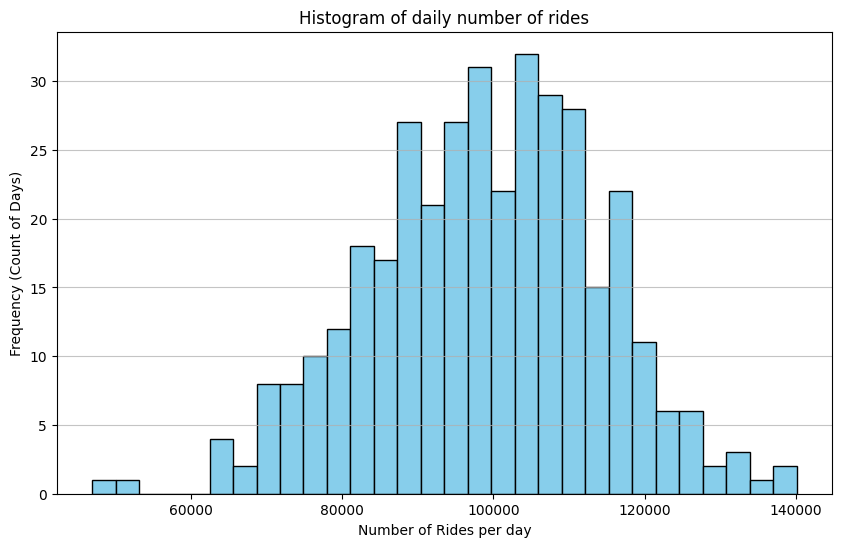

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(daily_number_of_rides["number_of_rides"], bins=30, color="skyblue", edgecolor="black")
plt.title("Histogram of daily number of rides")
plt.xlabel("Number of Rides per day")
plt.ylabel("Frequency (Count of Days)")
plt.grid(axis='y', alpha=0.75)
plt.show()

### Line plot, date vs number of rides (remember to sort by date)

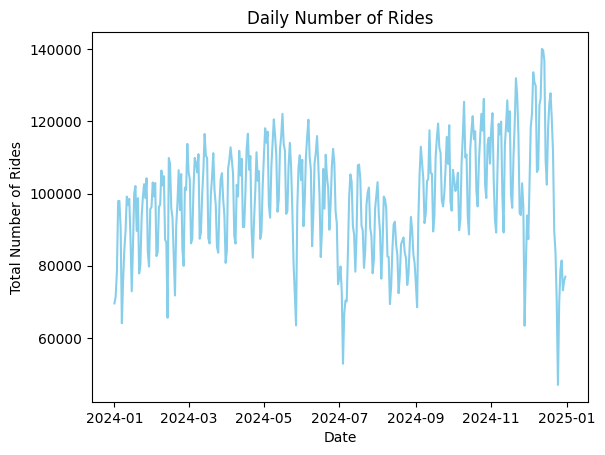

In [ ]:
plt.plot(
    daily_number_of_rides["date"],
    daily_number_of_rides["number_of_rides"],
    color="skyblue"
)
plt.title("Daily Number of Rides")
plt.xlabel("Date")
plt.ylabel("Total Number of Rides")
plt.show()